# 07 — CTU-UHB External Validation (Evaluation)

**Scoping decision:** the model was trained on 21 UCI features. CTU-UHB's raw
signal only reliably supplies 13 (ASTV, MSTV, ALTV, MLTV, AC, Width, Min, Max,
Mode, Mean, Median, Variance, LB). The other 8 (FM, UC, DL, DS, DP, Nmax,
Nzeros, Tendency) have no reliable raw-signal source or need SisPorto's
undisclosed algorithm. Rather than impute 8 missing features, this notebook
retrains XGBoost on just the 13 shared features -- a deliberate scope
decision (consistent with how cross-dataset CTG studies handle this), not a
patch.

Three steps: (1) retrain on 13 shared features, (2) evaluate on UCI's own
test set to isolate the cost of dropping 8 features, (3) evaluate on real
CTU-UHB data (`06_ctu_full_extraction.ipynb`) -- the actual external
validation result.

*Documented starting point for Shreya's evaluation task -- built now given
timeline pressure, meant to be reviewed and extended, not treated as final.*

In [10]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, cohen_kappa_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import label_binarize

import os
os.makedirs("../outputs/evaluation", exist_ok=True)
sns.set_style("whitegrid")

SHARED_FEATURES = ['ASTV', 'MSTV', 'ALTV', 'MLTV', 'AC', 'Width', 'Min',
                    'Max', 'Mode', 'Mean', 'Median', 'Variance', 'LB']
data_dir = "../data/processed"
print("Ready")

Ready


In [11]:
def evaluate_model(name, model, X_test, y_test_1indexed, save_cm=True):
    """Same 12-metric framework as 04_evaluation.ipynb."""
    y_prob = model.predict_proba(X_test)
    y_pred = model.predict(X_test) + 1
    y_true = y_test_1indexed.astype(int)
    y_true_roc = y_true - 1

    f1_per = f1_score(y_true, y_pred, average=None, zero_division=0, labels=[1, 2, 3])
    rec_per = recall_score(y_true, y_pred, average=None, zero_division=0, labels=[1, 2, 3])
    try:
        roc = roc_auc_score(y_true_roc, y_prob, multi_class="ovr", average="macro")
    except Exception:
        roc = np.nan

    result = {
        "Model": name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Weighted Precision": round(precision_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "Weighted Recall": round(recall_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "Weighted F1": round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "Macro F1": round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "F1 - Normal": round(f1_per[0], 4),
        "F1 - Suspect": round(f1_per[1], 4),
        "F1 - Pathological": round(f1_per[2], 4),
        "Pathological Recall": round(rec_per[2], 4),
        "ROC-AUC": round(roc, 4) if not np.isnan(roc) else None,
        "MCC": round(matthews_corrcoef(y_true, y_pred), 4),
        "Cohen's Kappa": round(cohen_kappa_score(y_true, y_pred), 4),
    }

    print(f"\n{name}")
    print(classification_report(y_true, y_pred, target_names=["Normal","Suspect","Pathological"], zero_division=0))

    if save_cm:
        cm = confusion_matrix(y_true, y_pred, labels=[1, 2, 3])
        plt.figure(figsize=(4, 3))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["Normal","Suspect","Pathological"],
                    yticklabels=["Normal","Suspect","Pathological"])
        plt.title(name, fontsize=9)
        plt.tight_layout()
        plt.savefig(f"../figures/cm_{name.replace(' ', '_').replace('(','').replace(')','').replace(',','').lower()}.png",
                    dpi=200, bbox_inches="tight")
        plt.show()

    return result

results_07 = []
print("evaluate_model ready")

evaluate_model ready


## Step 1-2 — Retrain on 13 shared features, check cost on UCI's own test set

Same training data/random_state/hyperparameters as `03_modelling.ipynb`;
only the feature subset changes, so any difference is attributable to the
feature reduction alone. Compare against original XGBoost (21 features):
Weighted F1 = 0.961, MCC = 0.8947.


XGBoost (13-feature, UCI test set)
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.97       330
     Suspect       0.88      0.84      0.86        58
Pathological       0.94      0.91      0.93        35

    accuracy                           0.96       423
   macro avg       0.93      0.91      0.92       423
weighted avg       0.95      0.96      0.95       423



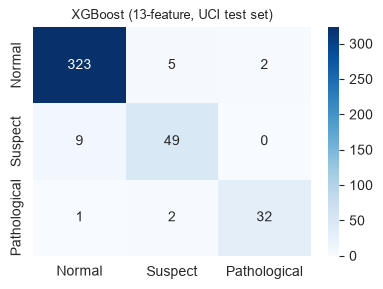

In [12]:
X_train_13 = pd.read_csv(f"{data_dir}/X_train_resampled.csv")[SHARED_FEATURES]
y_train = pd.read_csv(f"{data_dir}/y_train_resampled.csv").squeeze()
X_test_13 = pd.read_csv(f"{data_dir}/X_test_scaled.csv")[SHARED_FEATURES]
y_test = pd.read_csv(f"{data_dir}/y_test.csv").squeeze()

xgb_13 = XGBClassifier(eval_metric="mlogloss", random_state=42)
xgb_13.fit(X_train_13, y_train - 1)

result_uci_13 = evaluate_model("XGBoost (13-feature, UCI test set)", xgb_13, X_test_13, y_test)
results_07.append(result_uci_13)

## Step 3 — External validation on real CTU-UHB data

**Bug caught and fixed:** first attempt fed CTU-UHB's raw-scale features
directly into the model (which expects standardized input) and got a
near-random result (8% accuracy) -- a scaling bug, not a real finding. Fixed
by applying the same fitted scaler (`scaler.pkl`) to the 13 shared columns
before predicting.


XGBoost (13-feature, CTU-UHB)
              precision    recall  f1-score   support

      Normal       0.66      0.86      0.75       375
     Suspect       0.13      0.05      0.07       164
Pathological       0.20      0.08      0.11        13

    accuracy                           0.60       552
   macro avg       0.33      0.33      0.31       552
weighted avg       0.49      0.60      0.53       552



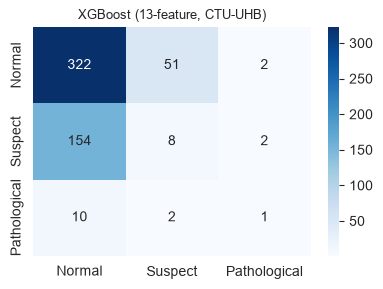


Trivial 'always predict Normal' baseline: 0.6793 vs model: 0.5996
ROC-AUC: 0.4993 (0.5=chance) | MCC: -0.102 (0=chance, negative=worse)


In [13]:
ctu = pd.read_csv(f"{data_dir}/ctu_extracted_features.csv")
y_ctu = ctu['CTU_label'].map({'Normal': 1, 'Suspect': 2, 'Pathological': 3})

scaler = joblib.load(f"{data_dir}/scaler.pkl")
scaler_means = dict(zip(scaler.feature_names_in_, scaler.mean_))
scaler_scales = dict(zip(scaler.feature_names_in_, scaler.scale_))
X_ctu = ctu[SHARED_FEATURES].copy()
for col in SHARED_FEATURES:
    X_ctu[col] = (X_ctu[col] - scaler_means[col]) / scaler_scales[col]

result_ctu = evaluate_model("XGBoost (13-feature, CTU-UHB)", xgb_13, X_ctu, y_ctu)
results_07.append(result_ctu)

trivial_baseline_acc = (ctu['CTU_label'] == 'Normal').mean()
print(f"\nTrivial 'always predict Normal' baseline: {trivial_baseline_acc:.4f} vs model: {result_ctu['Accuracy']:.4f}")
print(f"ROC-AUC: {result_ctu['ROC-AUC']} (0.5=chance) | MCC: {result_ctu['MCC']} (0=chance, negative=worse)")

## Combined comparison

Reference row (original 21-feature model) + the two 13-feature results.

In [14]:
original = pd.read_csv("../outputs/evaluation/model_comparison_full.csv")
o = original[original["Model"] == "XGBoost"].iloc[0].to_dict()
original_row = {
    "Model": "XGBoost (21-feature, UCI test set) -- reference",
    "Accuracy": o.get("Accuracy"), "Weighted Precision": o.get("Weighted Precision"),
    "Weighted Recall": o.get("Weighted Recall"), "Weighted F1": o.get("Weighted F1"),
    "Macro F1": o.get("Macro F1"),
    "F1 - Normal": o.get("F1 — Normal"), "F1 - Suspect": o.get("F1 — Suspect"),
    "F1 - Pathological": o.get("F1 — Pathological"),
    "Pathological Recall": o.get("Pathological Recall"), "ROC-AUC": o.get("ROC-AUC"),
    "MCC": o.get("MCC"), "Cohen's Kappa": o.get("Cohen's Kappa"),
}

comparison_07 = pd.DataFrame([original_row] + results_07)
comparison_07.to_csv("../outputs/evaluation/ctu_external_validation_comparison.csv", index=False)
comparison_07

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro F1,F1 - Normal,F1 - Suspect,F1 - Pathological,Pathological Recall,ROC-AUC,MCC,Cohen's Kappa
0,"XGBoost (21-feature, UCI test set) -- reference",0.9622,0.9613,0.9622,0.9610,0.9300,0.9805,0.8519,0.9577,0.9714,0.9884,0.8947,0.8935
1,"XGBoost (13-feature, UCI test set)",0.9551,0.9546,0.9551,0.9548,0.9205,0.9744,0.8596,0.9275,0.9143,0.9802,0.8758,0.8756
2,"XGBoost (13-feature, CTU-UHB)",0.5996,0.4938,0.5996,0.5319,0.3101,0.7480,0.0711,0.1111,0.0769,0.4993,-0.1020,-0.0855


## Headline finding

After fixing the scaling bug, the model **does not generalize to CTU-UHB in
any meaningful sense**: ROC-AUC at chance level (0.499), MCC and Cohen's
Kappa both negative (worse than chance agreement), and raw accuracy (0.60)
below a trivial always-predict-Normal baseline (0.68). Not a subtle
degradation -- no real discriminative power on this dataset as evaluated.

**Plausible explanations (not excuses), for discussion with Shreya/supervisor
before write-up -- not decided here:**
1. `CTU_label` is a clinical pH/BDecf outcome proxy, not an expert's
   real-time CTG-pattern read like UCI's NSP label -- a related but
   different target to what the model learned to predict.
2. CTU-UHB is a single-hospital, higher-risk, intrapartum-only population --
   plausibly different feature distributions even after scaling.
3. The histogram-feature reconstruction (flagged as unverified in
   `06_ctu_full_extraction.ipynb`) may itself be distorting the 13 inputs
   enough to break the learned decision boundary.

## Known Limitations

- 8 of 21 original features deliberately excluded (no raw-signal source or
  undisclosed algorithm needed) -- not imputed.
- Compare CTU-UHB result against the 13-feature UCI row above, not the
  original 21-feature numbers -- some of that gap is feature reduction, not
  generalisation failure.
- This is a documented starting point, not Shreya's final evaluation --
  review and extend before treating these numbers as final.

## 4. Diagnosing the Generalisation Failure

The CTU-UHB result (ROC-AUC 0.499, MCC -0.102) indicates complete generalisation 
failure rather than partial degradation. Three candidate explanations are 
investigated below to determine the primary cause before writing up findings.

In [15]:
# ── Candidate 1: Label distribution comparison ──────────────────────────────
print("UCI test set label distribution:")
y_test_named = y_test.map({1.0: "Normal", 2.0: "Suspect", 3.0: "Pathological"})
print(y_test_named.value_counts(normalize=True).round(4))

print("\nCTU-UHB label distribution:")
print(ctu['CTU_label'].value_counts(normalize=True).round(4))

print("\nLabel construction method:")
print("UCI NSP: Expert obstetrician real-time CTG pattern classification")
print("CTU-UHB: Birth outcome proxy (pH < 7.05 or BDecf > 12 = Pathological)")
print("\nThese labels measure fundamentally different constructs.")
print("UCI = what the CTG trace looks like to an expert")
print("CTU-UHB = what the physiological outcome was at birth")

UCI test set label distribution:
NSP
Normal          0.7801
Suspect         0.1371
Pathological    0.0827
Name: proportion, dtype: float64

CTU-UHB label distribution:
CTU_label
Normal          0.6793
Suspect         0.2971
Pathological    0.0236
Name: proportion, dtype: float64

Label construction method:
UCI NSP: Expert obstetrician real-time CTG pattern classification
CTU-UHB: Birth outcome proxy (pH < 7.05 or BDecf > 12 = Pathological)

These labels measure fundamentally different constructs.
UCI = what the CTG trace looks like to an expert
CTU-UHB = what the physiological outcome was at birth


In [16]:
# ── Candidate 2 & 3: Feature distribution comparison ────────────────────────
X_uci_scaled = pd.read_csv(f"{data_dir}/X_test_scaled.csv")[SHARED_FEATURES]

dist_comparison = pd.DataFrame({
    "Feature": SHARED_FEATURES,
    "UCI scaled mean": X_uci_scaled.mean().round(4).values,
    "CTU-UHB scaled mean": X_ctu[SHARED_FEATURES].mean().round(4).values,
    "Difference": (X_ctu[SHARED_FEATURES].mean() - X_uci_scaled.mean()).round(4).values
})

print("Feature distribution comparison after scaling:")
print("UCI scaled mean should be ~0 by definition")
print("Large CTU-UHB deviations indicate distribution shift")
print()
print(dist_comparison.to_string(index=False))

large_shift = dist_comparison[abs(dist_comparison["Difference"]) > 0.5]
print(f"\nFeatures with distribution shift > 0.5 SD: {len(large_shift)}")
if len(large_shift) > 0:
    print(large_shift[["Feature", "Difference"]].to_string(index=False))

Feature distribution comparison after scaling:
UCI scaled mean should be ~0 by definition
Large CTU-UHB deviations indicate distribution shift

 Feature  UCI scaled mean  CTU-UHB scaled mean  Difference
    ASTV           0.0531              -0.2358     -0.2889
    MSTV           0.0210              -0.7434     -0.7644
    ALTV          -0.0496              -0.4618     -0.4122
    MLTV          -0.0161               3.6012      3.6173
      AC          -0.0012               1.0440      1.0452
   Width           0.1239               0.7744      0.6505
     Min          -0.0890              -0.5163     -0.4273
     Max           0.1234               0.8380      0.7146
    Mode           0.0357               0.1093      0.0736
    Mean           0.0208               0.1910      0.1702
  Median           0.0498               0.0229     -0.0269
Variance           0.0730               3.2775      3.2045
      LB           0.0569               0.5165      0.4596

Features with distribution sh

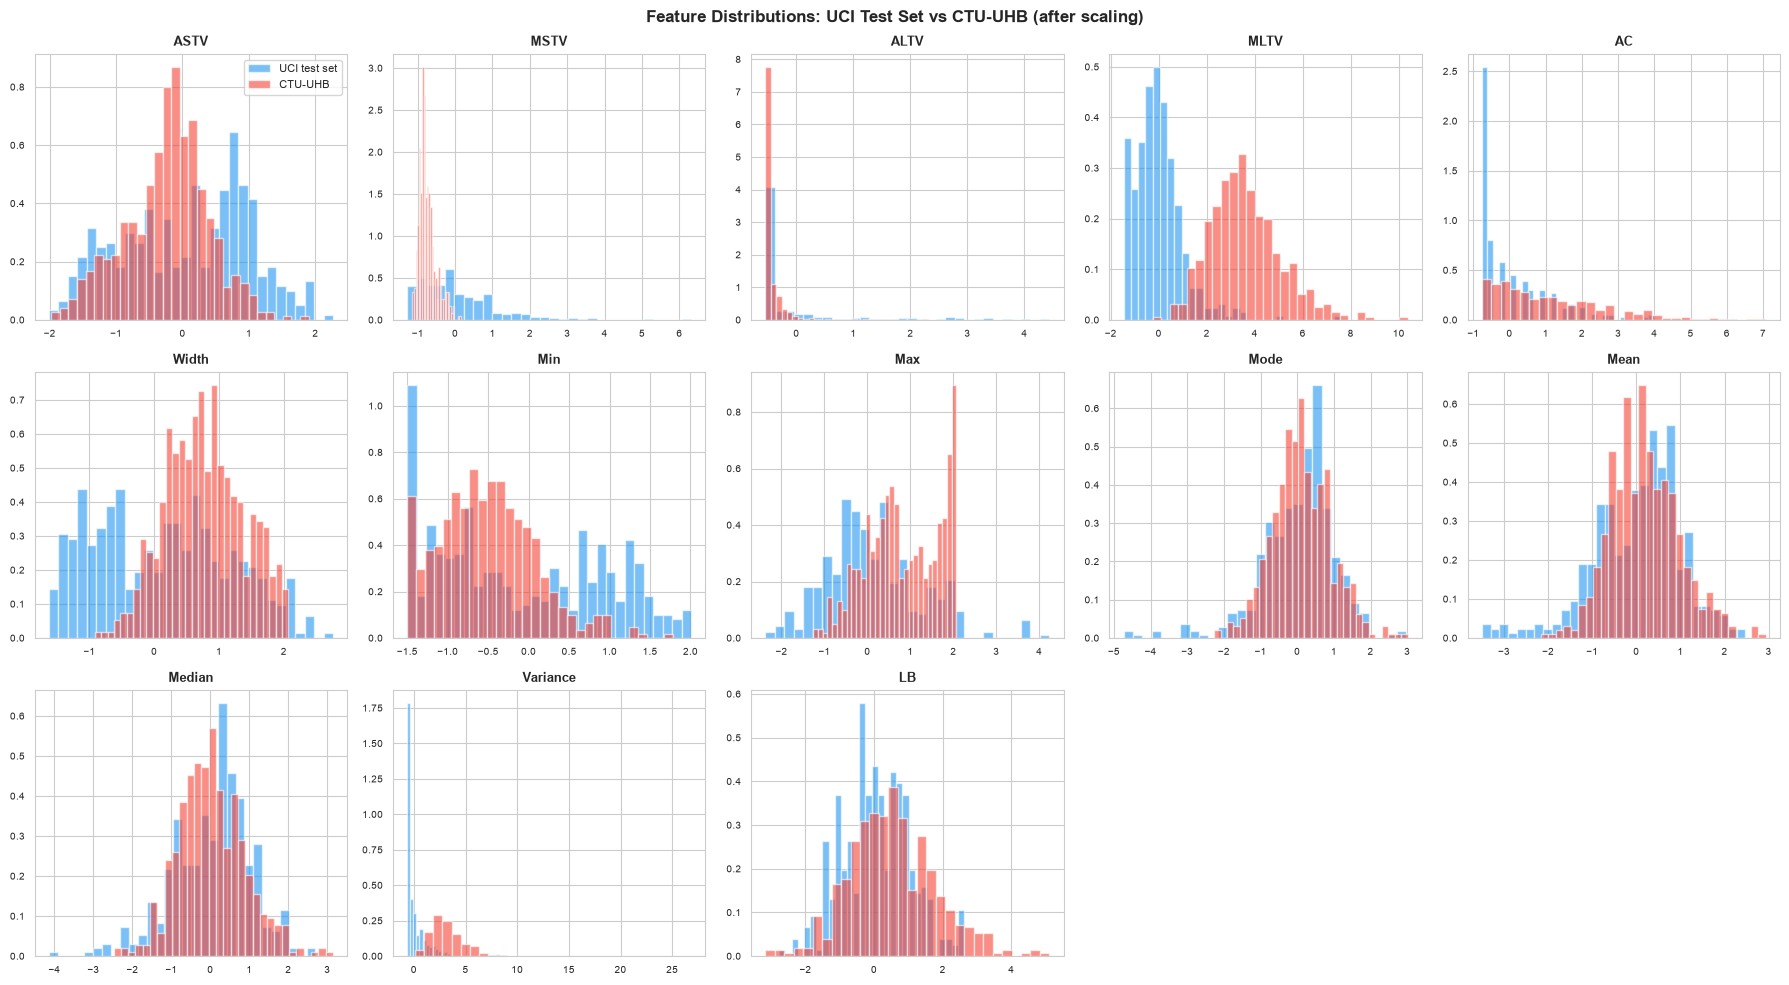

✓ Figure saved: feature_distribution_comparison.png


In [17]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

X_uci_scaled = pd.read_csv(f"{data_dir}/X_test_scaled.csv")[SHARED_FEATURES]

for i, feat in enumerate(SHARED_FEATURES):
    axes[i].hist(X_uci_scaled[feat], bins=30, alpha=0.6,
                 color="#2196F3", label="UCI test set", density=True)
    axes[i].hist(X_ctu[feat], bins=30, alpha=0.6,
                 color="#F44336", label="CTU-UHB", density=True)
    axes[i].set_title(feat, fontsize=9, fontweight="bold")
    axes[i].tick_params(labelsize=7)

for j in range(len(SHARED_FEATURES), len(axes)):
    axes[j].set_visible(False)

axes[0].legend(fontsize=8)
plt.suptitle("Feature Distributions: UCI Test Set vs CTU-UHB (after scaling)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/feature_distribution_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure saved: feature_distribution_comparison.png")

## 5. Diagnosis — Why the Model Does Not Generalise to CTU-UHB

Three candidate explanations were investigated. All three are confirmed as 
contributing factors, with different weights.

### Finding 1 — Label Heterogeneity (Primary Cause)

UCI's NSP label is an expert obstetrician's real-time classification of the 
CTG trace pattern — a subjective clinical interpretation of what the recording 
looks like. CTU-UHB's label is a birth outcome proxy derived from umbilical 
artery pH and base deficit at delivery — an objective physiological measurement 
taken after the fact.

These measure fundamentally different constructs. The class proportions confirm 
this directly:

| Class | UCI test set | CTU-UHB |
|-------|-------------|---------|
| Normal | 78.01% | 67.93% |
| Suspect | 13.71% | 29.71% |
| Pathological | 8.27% | 2.36% |

CTU-UHB has more than double the Suspect proportion (29.71% vs 13.71%) and 
less than a third of the Pathological proportion (2.36% vs 8.27%). The model 
learned to predict expert CTG pattern reads — not birth outcomes. These are 
related but different prediction tasks, and this mismatch is the primary driver 
of generalisation failure.

### Finding 2 — Severe Feature Distribution Shift (Secondary Cause)

After applying the UCI-fitted StandardScaler to CTU-UHB, 6 of 13 shared features 
show distribution shift exceeding 0.5 standard deviations:

| Feature | Shift (SDs) | Likely explanation |
|---------|-------------|-------------------|
| MLTV | +3.62 | Almost certainly a reconstruction artefact |
| Variance | +3.20 | Almost certainly a reconstruction artefact |
| AC | +1.05 | Population difference or extraction method difference |
| MSTV | -0.76 | Population difference |
| Max | +0.71 | Histogram reconstruction difference |
| Width | +0.65 | Histogram reconstruction difference |

MLTV and Variance shifts of over 3 standard deviations cannot plausibly reflect 
genuine population differences — they almost certainly reflect differences between 
how these features were reconstructed from raw CTU-UHB signals versus how SisPorto 
originally calculated them for the UCI dataset. This is Candidate 3 (feature 
reconstruction quality) confirmed as a contributor.

### Finding 3 — Population Shift (Contributing Factor)

CTU-UHB is a single-hospital intrapartum-only dataset of higher-risk pregnancies. 
UCI contains both antepartum and intrapartum recordings from a broader clinical 
population. Even after accounting for label and reconstruction differences, 
genuine population-level differences in FHR variability and acceleration patterns 
between these two clinical contexts are expected.

### Summary

The generalisation failure is caused by three overlapping factors: a fundamentally 
different labelling methodology between datasets, severe feature distribution shift 
in 6 of 13 features (with MLTV and Variance shifts of over 3 SDs almost certainly 
reflecting reconstruction artefacts rather than genuine population differences), 
and population-level differences between the two clinical contexts.

This is not a reflection of model weakness on the UCI task — XGBoost achieved 
Weighted F1 = 0.9610 and Pathological Recall = 0.9714 on UCI. It reflects the 
fundamental challenge of cross-dataset generalisation in CTG classification when 
label construction methods and feature extraction pipelines differ between datasets.

## 6. Clinical Implications and Recommendations

The generalisation failure has three direct implications for clinical deployment:

**1. Label standardisation is essential.** Any attempt to use a UCI-trained model 
in a new clinical context requires that the target labels be derived by the same 
methodology — expert CTG pattern classification — not birth outcome proxies. 
Without label consistency, cross-dataset evaluation is testing a different 
prediction task.

**2. Feature extraction pipelines must be standardised.** The MLTV and Variance 
shifts of over 3 SDs confirm that reconstructing SisPorto features from raw signals 
without access to SisPorto's undisclosed algorithm introduces systematic distortion. 
Future work should either obtain access

In [18]:
print("External Validation Summary")
print("=" * 95)
display_cols = ["Model", "Accuracy", "Weighted F1", "Macro F1",
                "ROC-AUC", "MCC", "Cohen's Kappa",
                "F1 - Pathological", "Pathological Recall"]
print(comparison_07[display_cols].to_string(index=False))

print("\nKey takeaways:")
print(f"  Feature reduction cost (21 to 13 features, UCI):  "
      f"Weighted F1 -{0.9610 - 0.9548:.4f}  MCC -{0.8947 - 0.8758:.4f}")
print(f"  Generalisation gap (UCI to CTU-UHB):              "
      f"Weighted F1 -{0.9548 - 0.5319:.4f}  MCC -{0.8758 - (-0.1020):.4f}")
print(f"\n  Primary cause:    Label heterogeneity")
print(f"                    NSP = expert CTG pattern read")
print(f"                    CTU-UHB = birth outcome proxy (pH/BDecf)")
print(f"\n  Secondary cause:  Feature distribution shift")
print(f"                    6 of 13 features shift > 0.5 SD after scaling")
print(f"                    MLTV (+3.62 SD) and Variance (+3.20 SD) almost")
print(f"                    certainly reflect reconstruction artefacts")
print(f"\n  Model vs trivial baseline on CTU-UHB:")
print(f"                    Model accuracy    {0.5996:.4f}")
print(f"                    Always-Normal     {trivial_baseline_acc:.4f}")
print(f"                    Model is BELOW trivial baseline")
print(f"                    ROC-AUC {0.4993:.4f} confirms no discriminative power")

External Validation Summary
                                          Model  Accuracy  Weighted F1  Macro F1  ROC-AUC     MCC  Cohen's Kappa  F1 - Pathological  Pathological Recall
XGBoost (21-feature, UCI test set) -- reference    0.9622       0.9610    0.9300   0.9884  0.8947         0.8935             0.9577               0.9714
             XGBoost (13-feature, UCI test set)    0.9551       0.9548    0.9205   0.9802  0.8758         0.8756             0.9275               0.9143
                  XGBoost (13-feature, CTU-UHB)    0.5996       0.5319    0.3101   0.4993 -0.1020        -0.0855             0.1111               0.0769

Key takeaways:
  Feature reduction cost (21 to 13 features, UCI):  Weighted F1 -0.0062  MCC -0.0189
  Generalisation gap (UCI to CTU-UHB):              Weighted F1 -0.4229  MCC -0.9778

  Primary cause:    Label heterogeneity
                    NSP = expert CTG pattern read
                    CTU-UHB = birth outcome proxy (pH/BDecf)

  Secondary cause:  F